# Ensemble Learning: Boosting

In Lesson 10, we explored **Bagging** (Random Forests). That architecture operated on the principle of democracy: build 500 massive, independent Decision Trees in parallel, let them all overfit in completely different ways, and average their answers together to cancel out the noise. Bagging is explicitly designed to reduce **Variance**.

**Boosting** is the exact opposite philosophy. It operates on the principle of sequential correction. Instead of building 500 massive trees in parallel, we build 500 tiny, mathematically weak trees *one after another*. Tree #2's entire purpose is to mathematically correct the specific mistakes made by Tree #1. Boosting is explicitly designed to reduce **Bias** (though it can reduce variance, too).

If you are entering an enterprise Machine Learning role, mastering Boosting (specifically XGBoost and LightGBM) is non-negotiable. It is the algorithm that wins almost every structured-data Kaggle competition on Earth.

While there are many variations (AdaBoost, Gradient Boosting, XGBoost), the modern enterprise standard is **Gradient Boosting**. In this lesson, we will unpack the calculus and sequence that makes this algorithm so ruthlessly accurate.

Let's set up our Python environment to visualize sequential learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Sequential Optimization Environment Ready.")

✅ Sequential Optimization Environment Ready.


# 1. The Mathematics of Gradient Boosting

Gradient Boosting combines the two most powerful concepts we have learned so far: the spatial logic of **Decision Trees** (Lesson 08) and the calculus engine of **Gradient Descent** (Lesson 02).

In a Random Forest, every tree tries to predict the Target Vector ($y$). In Gradient Boosting, only the very first step predicts $y$. Every subsequent tree tries to predict the **Residuals** (the error).

### Step 1: The Base Model ($F_0$)
The algorithm starts with an incredibly dumb baseline prediction. For Regression (Mean Squared Error), this is simply the average of all the $y$ values.
$$F_0(x) = \frac{1}{n} \sum_{i=1}^{n} y_i$$

### Step 2: Calculate the Pseudo-Residuals ($r_{im}$)
For every row in our dataset, the algorithm calculates exactly how wrong the current model is. If the true target is $100$ and our base model predicted $60$, the residual is $40$. 

Mathematically, this residual is actually the negative gradient of the Cost Function. We are calculating the slope of the error for every individual data point!
$$r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}$$
*(For Mean Squared Error, this terrifying calculus formula perfectly simplifies to just: $y_i - F_{m-1}(x_i)$).*

### Step 3: Train a "Weak Learner" ($h_m$)
We now train a brand new, extremely shallow Decision Tree (usually just 3 or 4 levels deep). But here is the genius part: **We do not train it to predict $y$. We train it to predict the Residuals ($r_{im}$).**

### Step 4: The Update Rule (The Learning Rate)
We now add this new tree's predictions to our running total. However, if we add 100% of the tree's prediction, the algorithm will overfit instantly. We must apply a **Learning Rate ($\nu$)** to shrink the tree's contribution, forcing the algorithm to learn slowly.
$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

*(We repeat Steps 2-4 hundreds of times. Each tree takes a tiny, mathematically optimized bite out of the remaining error!)*

# 2. Visualizing the Sequence in Code

Let's simulate a complex sine wave. We will train a Gradient Boosting model and explicitly look at how the prediction curve changes over time using `staged_predict()`.

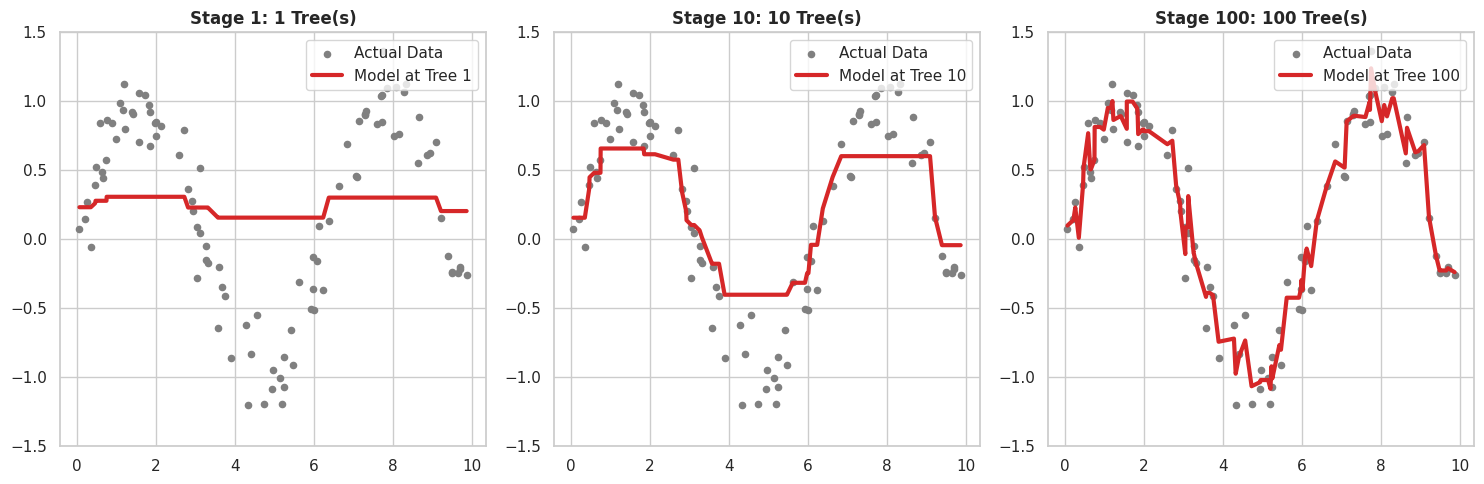

In [2]:
# 1. Simulate a complex curve with noise
np.random.seed(42)
X = np.sort(np.random.rand(100) * 10).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.randn(100) * 0.2

# 2. Train a Gradient Boosting Regressor
# We use 100 estimators (trees) and a shallow depth of 3
gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(X, y)

# 3. Matplotlib Visualization of Sequential Learning
plt.figure(figsize=(15, 5))
stages = [1, 10, 100] # We will look at Tree 1, Tree 10, and Tree 100

for i, stage in enumerate(stages):
    plt.subplot(1, 3, i+1)
    plt.scatter(X, y, color='gray', s=20, label='Actual Data')
    
    # Extract the prediction at this exact stage in the sequence
    # staged_predict returns a generator of predictions at each stage
    y_pred_stage = list(gbm.staged_predict(X))[stage-1]
    
    plt.plot(X, y_pred_stage, color='#d62728', linewidth=3, label=f'Model at Tree {stage}')
    plt.title(f"Stage {stage}: {stage} Tree(s)", fontweight='bold')
    plt.ylim(-1.5, 1.5)
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

*(Insight: Look closely at the progression. At Stage 1, the model is basically drawing a single horizontal block (a massive underfit). By Stage 10, it has roughed out the shape of the sine wave. By Stage 100, the accumulation of 100 tiny, weak trees has sculpted a beautifully precise curve that cuts perfectly through the noise!)*

# 3. The Grand Tradeoff: Learning Rate vs. Number of Trees

In a Random Forest, more trees is *always* better (or at least, it won't hurt). You can set `n_estimators=2000` and walk away.

**In Gradient Boosting, more trees will eventually cause catastrophic Overfitting.** Because the algorithm actively targets errors, if you let it run forever, it will eventually start building trees specifically to target the random noise.

This creates an intense, linked hyperparameter tradeoff between `learning_rate` ($\nu$) and `n_estimators` ($M$):
* **High Learning Rate (e.g., $0.5$)**: Takes massive steps. Requires very few trees to converge. Extremely high risk of overfitting and missing the global minimum.
* **Low Learning Rate (e.g., $0.01$)**: Takes microscopic steps. Requires thousands of trees to converge. Highly robust and generalized, but takes a massive amount of server time to compute.

# 4. The Evolution: XGBoost and LightGBM

While `scikit-learn`'s implementation of Gradient Boosting is excellent for learning, the enterprise world uses specialized libraries.

* **XGBoost (eXtreme Gradient Boosting)**: Revolutionized ML by introducing deep hardware optimization (parallelized tree building on the CPU/GPU cache) and adding **L1/L2 Regularization** directly into the tree-building math to aggressively prevent overfitting. It also uses the Second Derivative (the Hessian) of the Cost Function, not just the first, allowing it to find minimums much faster.
* **LightGBM**: Created by Microsoft, it uses a "leaf-wise" tree growth strategy instead of "level-wise". It is often significantly faster than XGBoost on massive datasets with millions of rows.

---

## Real-World Analogy:
Think of the difference between Bagging and Boosting like **Playing Golf**:

* **Bagging (Random Forest)**: You invite 500 professional golfers to the tee. You blindfold them slightly, spin them around, and ask them all to hit a ball toward the hole at the exact same time. They all hit the ball to completely different spots. You walk out, find the exact geographic center (the average) of the 500 balls, and place your final ball there.
* **Boosting (Gradient Boosting)**: You play the hole yourself. 
    * **The Base Prediction**: You hit a powerful drive off the tee. You are 150 yards short of the hole. (Your Residual is 150 yards).
    * **Tree 1**: You do not aim for the hole from the tee box again. You walk to where your ball landed. Your next shot is an iron shot aiming to cover the *remaining 150 yards*. You hit it, but the wind blows it 10 yards to the right. (Your new Residual is 10 yards).
    * **Tree 2**: You pull out a putter and aim to cover the *remaining 10 yards*. 
    * Every single shot (Tree) exists purely to correct the distance left over by the previous shot!

---